# VIDEMUS — Traffic Light Detection Model
### AR Driving Guidance — Baseline Model

This notebook fine-tunes a YOLOv8 model to detect traffic lights
and their states (red, yellow, green) from driving footage.

**Requirements:** Run on Google Colab with GPU runtime enabled.
Go to Runtime → Change runtime type → T4 GPU

#1. Install required packages

In [1]:
!pip install ultralytics roboflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 126.3 MB/s eta 0:00:00


### Verify GPU availability

In [2]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


#2. Download Traffic Light Dataset
We use a pre-labeled traffic light dataset from Roboflow. <br>
It contains annotated images of traffic lights in three states:<br>
red, yellow, and green — captured from driving footage.

In [3]:
from roboflow import Roboflow
import os

In [4]:
ROBOFLOW_API_KEY = 'API'
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

# Download a traffic light detection dataset

In [5]:
project = rf.workspace("lenkaleeszabocapstone").project("traffic-light-detection-mlnz7")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Traffic-Light-Detection-1 in yolov8:: 100%|██████████| 19432/19432 [00:02<00:00, 6935.89it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [6]:
print(f"\nDataset downloaded to: {dataset.location}")


Dataset downloaded to: /content/Traffic-Light-Detection-1


# Explore the dataset structure

In [7]:
dataset_path = dataset.location
print("Dataset contents:")
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        file_count = len(files)
        if file_count > 5:
            print(f"{subindent}({file_count} files)")
        else:
            for file in files:
                print(f"{subindent}{file}")

Dataset contents:
Traffic-Light-Detection-1/
  README.roboflow.txt
  data.yaml
  README.dataset.txt
  train/
    images/
    labels/
  test/
    images/
    labels/
  valid/
    images/
    labels/


# Read the data.yaml to see class names

In [8]:
yaml_path = os.path.join(dataset_path, "data.yaml")
if os.path.exists(yaml_path):
    print(f"\n--- data.yaml ---")
    with open(yaml_path, 'r') as f:
        print(f.read())


--- data.yaml ---
names:
- green
- red
- yellow
nc: 3
roboflow:
  license: CC BY 4.0
  project: traffic-light-detection-mlnz7
  url: https://universe.roboflow.com/lenkaleeszabocapstone/traffic-light-detection-mlnz7/dataset/1
  version: 1
  workspace: lenkaleeszabocapstone
test: ../test/images
train: ../train/images
val: ../valid/images



# 3. Fine-tune YOLOv8 on Traffic Light Detection

 We start from a pre-trained YOLOv8n (nano) model then fine-tune <br>
 it specifically for traffic light detection.<br>

# **Why YOLOv8n (nano)?**

- Lightweight and fast — ideal for real-time AR applications <br>
- Runs well on phones and edge devices <br>
- Can be upgraded to YOLOv8s/m later for higher accuracy

In [9]:
from ultralytics import YOLO

# Load a pre-trained YOLOv8 nano model

In [10]:
model = YOLO("yolov8n.pt")

# Train the model

In [11]:
results = model.train(
    data=os.path.join(dataset_path, "data.yaml"),
    epochs=10,
    imgsz=640,
    batch=16,
    patience=10,
    name="videmus_traffic_light",
    verbose=True
)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Traffic-Light-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=videmus_traffic_light, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, o

In [11]:
print("\nTraining complete!")

# 4. Evaluate Model Performance
### Key metrics:
- **mAP50**: Mean Average Precision at 50% IoU — above 0.7 is strong
- **Precision**: Of all detections, how many were correct
- **Recall**: Of all real traffic lights, how many did we detect

### Evaluate on validation set

In [12]:
metrics = model.val()

print(f"\n{'='*50}")
print(f"  VIDEMUS Model — Evaluation Results")
print(f"{'='*50}")
print(f"  mAP50:      {metrics.box.map50:.4f}")
print(f"  mAP50-95:   {metrics.box.map:.4f}")
print(f"  Precision:  {metrics.box.mp:.4f}")
print(f"  Recall:     {metrics.box.mr:.4f}")
print(f"{'='*50}")

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1495.8±443.7 MB/s, size: 42.4 KB)
val: Scanning /content/Traffic-Light-Detection-1/valid/labels.cache... 811 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 811/811 243.0Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 17, len(boxes) = 1148. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 51/51 6.4it/s 8.0s
                   all        811       1148      0.941       0.82      0.865      0.615
                 green        313        457      0.916      0.766      0.828       0.55
                   red   

### Visualize training results

In [13]:
from IPython.display import Image, display
import glob

results_dir = "runs/detect/videmus_traffic_light"

### Training loss and metrics curves

Training curves:


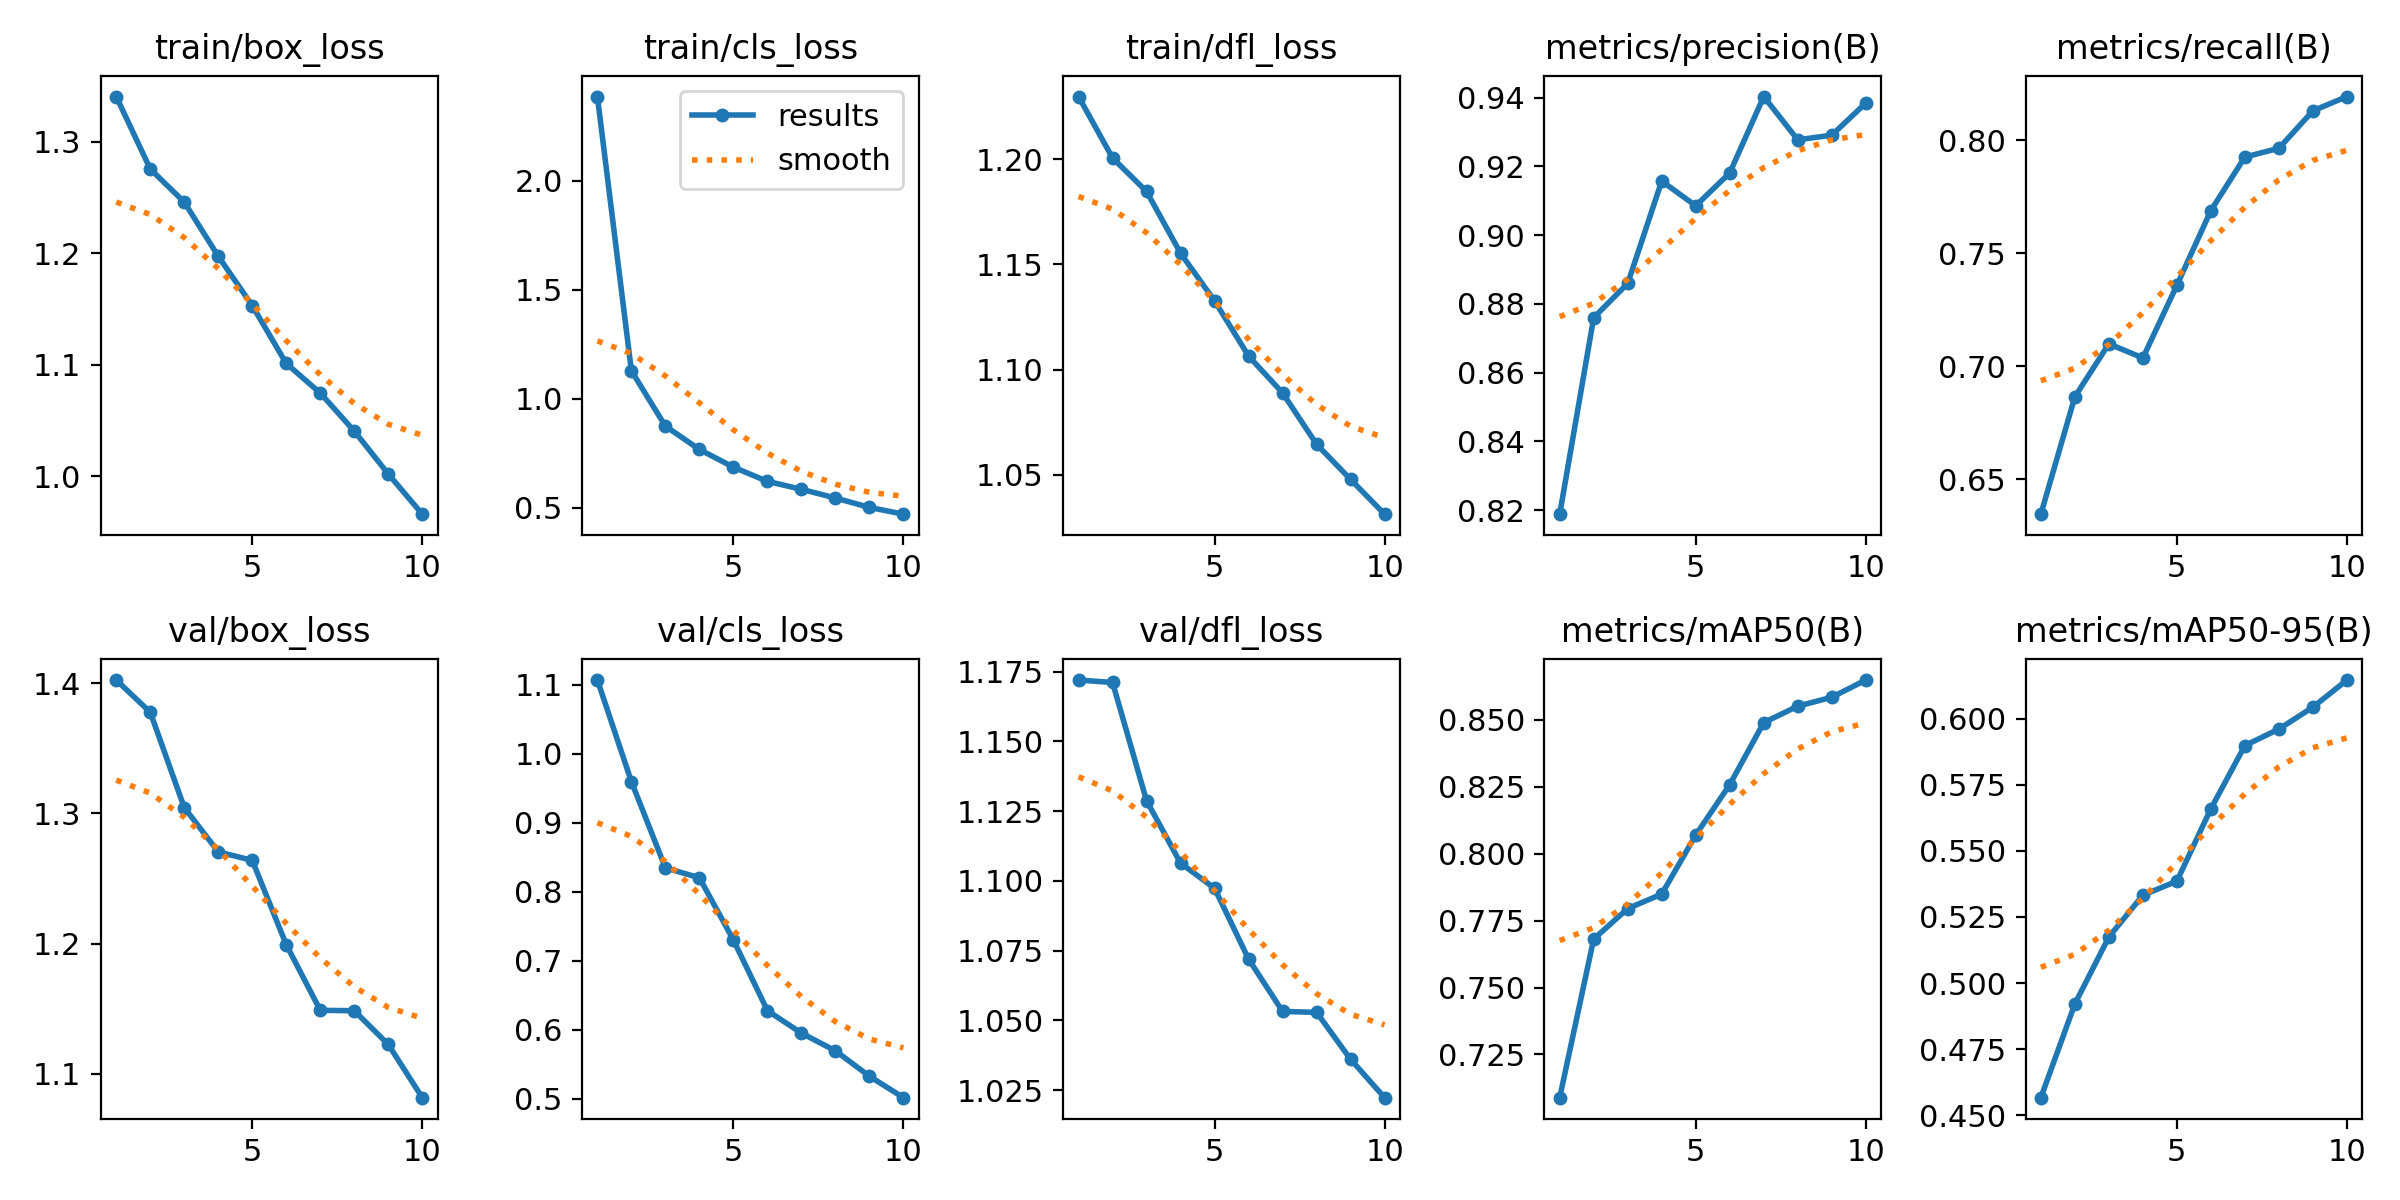

In [14]:
results_img = os.path.join(results_dir, "results.png")
if os.path.exists(results_img):
    print("Training curves:")
    display(Image(filename=results_img, width=900))

### Confusion matrix


Confusion matrix:


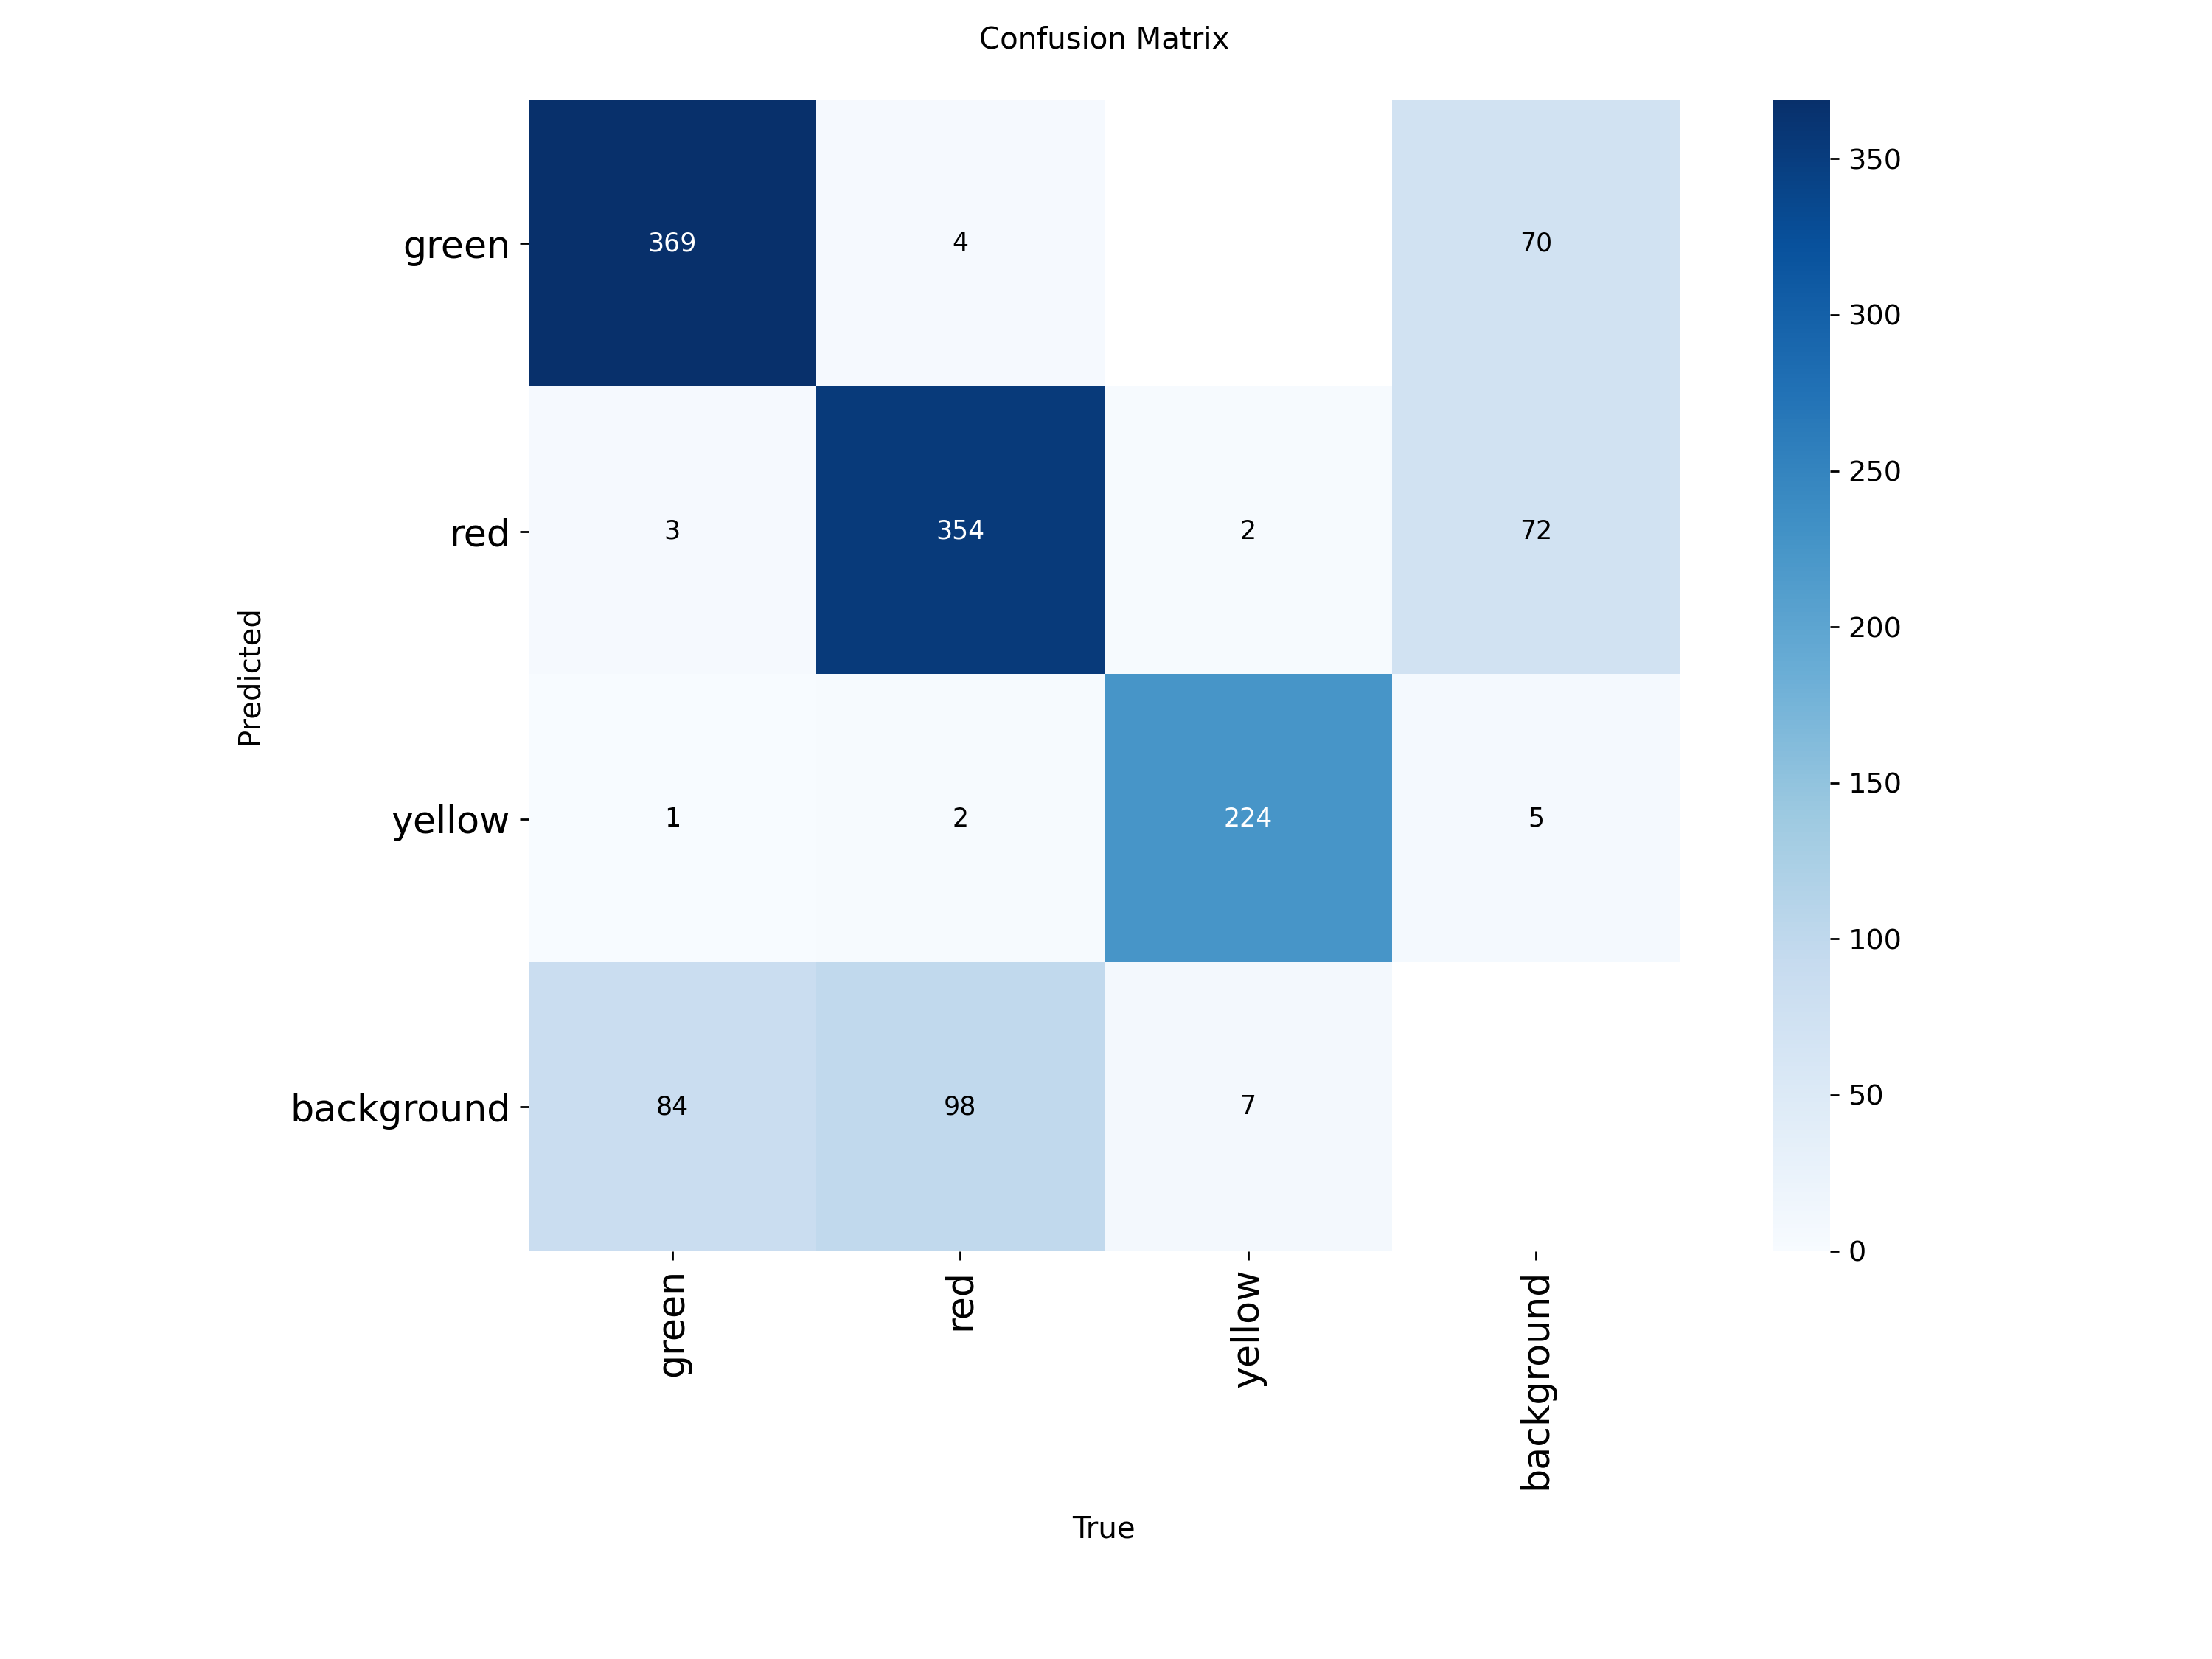

In [15]:
conf_img = os.path.join(results_dir, "confusion_matrix.png")
if os.path.exists(conf_img):
    print("\nConfusion matrix:")
    display(Image(filename=conf_img, width=600))

### Show sample predictions on validation images

Sample predictions on validation images:


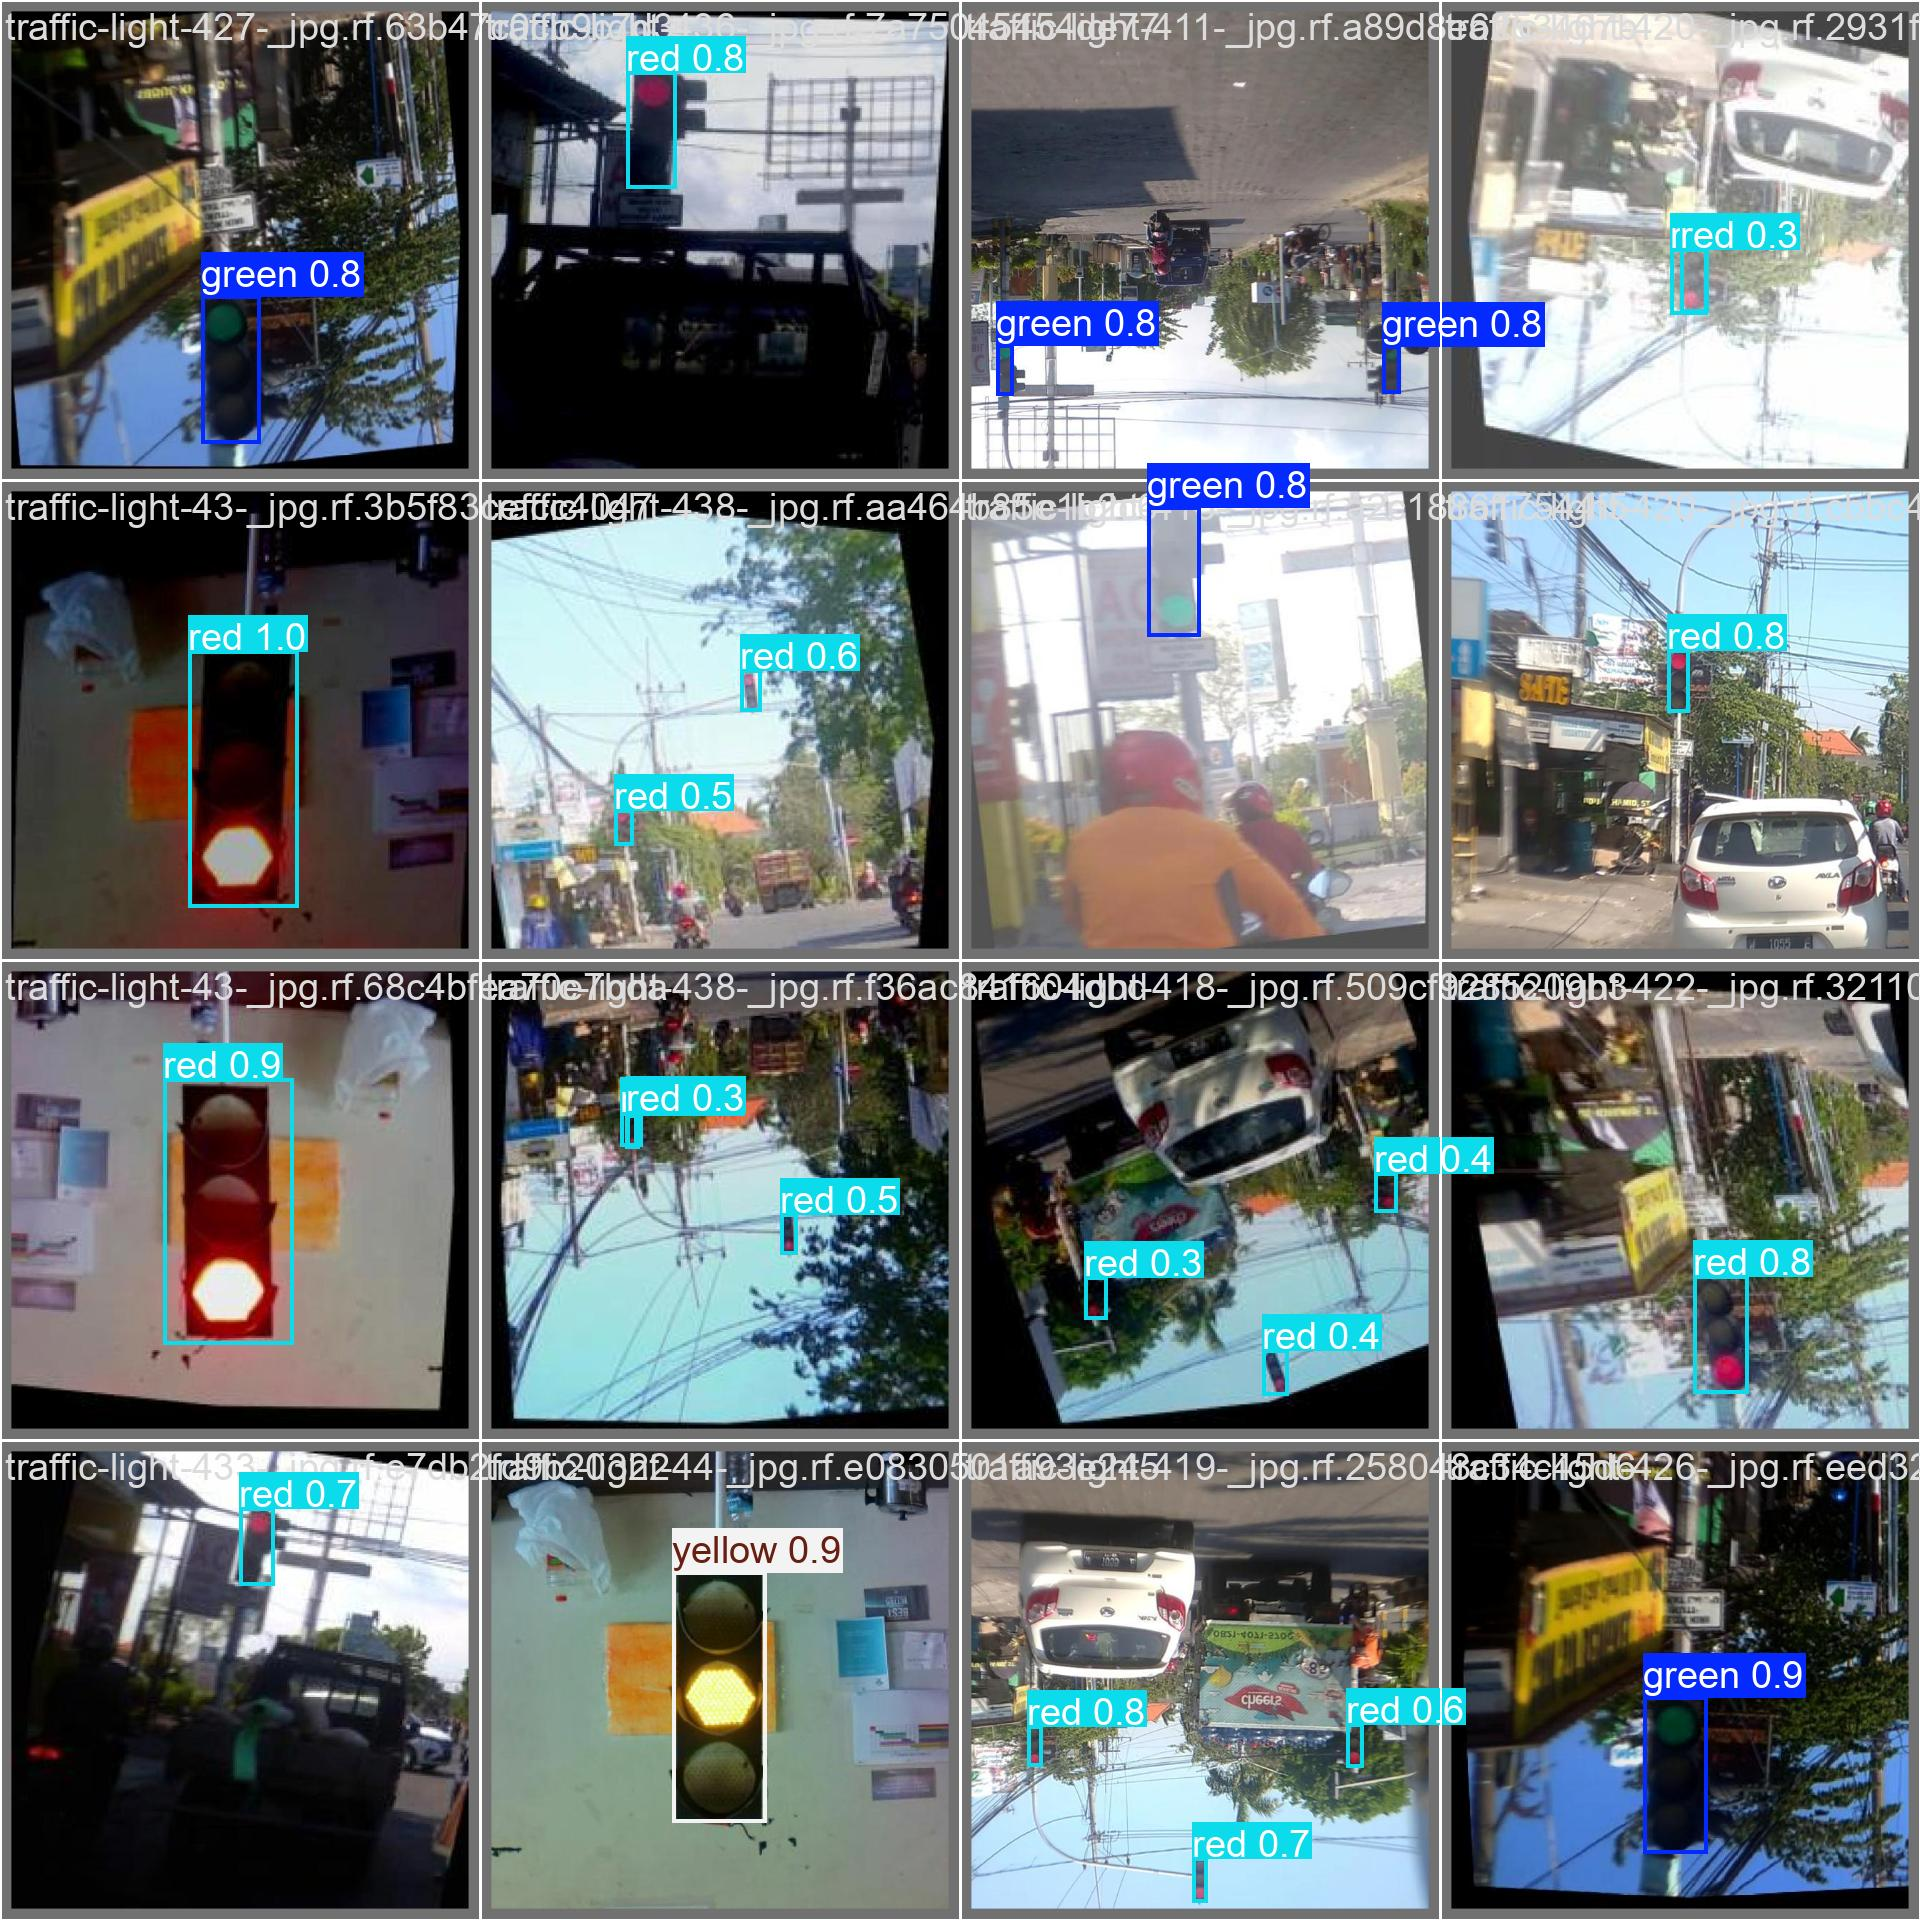

In [16]:
val_preds = os.path.join(results_dir, "val_batch0_pred.jpg")
if os.path.exists(val_preds):
    print("Sample predictions on validation images:")
    display(Image(filename=val_preds, width=900))

# 5. Test on Real Driving Footage
Upload a driving video to test the trained model. <br>
The model will draw bounding boxes around detected traffic lights.<br>
**Option A:** Upload your own video (next cell)<br>
**Option B:** Download from YouTube (cell after)